# [Lab 5-3] GAN (Generative Adversarial Network) 기반 MNIST 손글씨 숫자 생성 실습
---
이 노트북에서는 Generative Adversarial Network (GAN)를 구현하여 MNIST 손글씨 숫자를 생성합니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

I0000 00:00:1790680557.079080    6796 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790680557.079958    6796 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790680557.139516    6796 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790680558.868016    6796 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

## 1. 데이터 준비

In [2]:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.
x_train = np.expand_dims(x_train, -1)

BUFFER_SIZE = 60000
BATCH_SIZE = 256

train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

E0000 00:00:1790680560.610627    6796 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2. Generator 정의

In [3]:
def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))
    model.add(layers.Conv2DTranspose(128, (5,5), strides=(1,1), padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5,5), strides=(2,2), padding="same", use_bias=False, activation="tanh"))
    return model

generator = make_generator_model()
generator.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

## 3. Discriminator 정의

In [4]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5,5), strides=(2,2), padding="same", input_shape=[28,28,1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5,5), strides=(2,2), padding="same"))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))
    return model

discriminator = make_discriminator_model()
discriminator.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

## 4. 손실 함수와 Optimizer

In [5]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

## 5. 학습 루프 정의

In [6]:
EPOCHS = 30
noise_dim = 100
num_examples_to_generate = 16

seed = tf.random.normal([num_examples_to_generate, noise_dim])

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch in dataset:
            g_loss, d_loss = train_step(image_batch)
        print(f"Epoch {epoch+1}, Gen Loss: {g_loss:.4f}, Disc Loss: {d_loss:.4f}")

        generate_and_save_images(generator, epoch+1, seed)

def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4,4))

    for i in range(predictions.shape[0]):
        plt.subplot(4,4,i+1)
        plt.imshow(predictions[i,:,:,0]*127.5+127.5, cmap="gray")
        plt.axis("off")
    plt.suptitle(f"Epoch {epoch}")
    plt.show()

## 6. 모델 학습 실행

E0000 00:00:1790680563.793632    6796 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'gradient_tape/sequential_1_4/leaky_re_lu_3_1/LeakyRelu/LeakyReluGrad_1' exist for missing node 'sequential_1_4/conv2d_1/BiasAdd'.
E0000 00:00:1790680746.690772    6796 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'gradient_tape/sequential_1_4/leaky_re_lu_3_1/LeakyRelu/LeakyReluGrad_1' exist for missing node 'sequential_1_4/conv2d_1/BiasAdd'.


Epoch 1, Gen Loss: 0.9308, Disc Loss: 0.9750


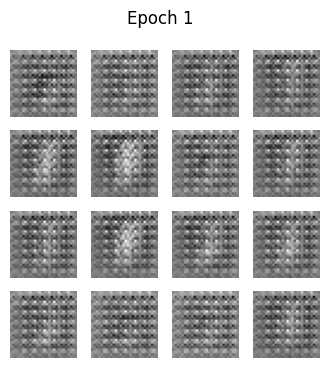

Epoch 2, Gen Loss: 0.6985, Disc Loss: 1.3195


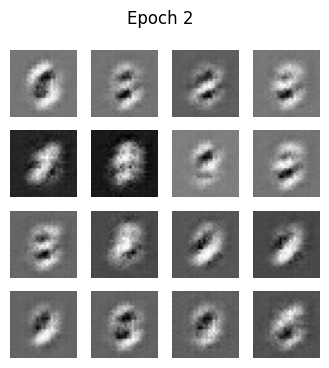

Epoch 3, Gen Loss: 0.8918, Disc Loss: 1.2890


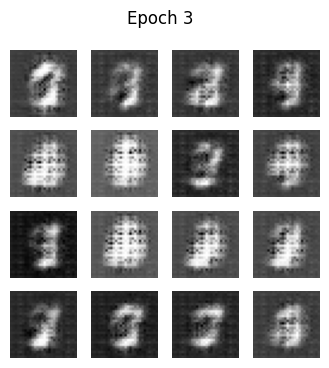

Epoch 4, Gen Loss: 1.0189, Disc Loss: 0.9665


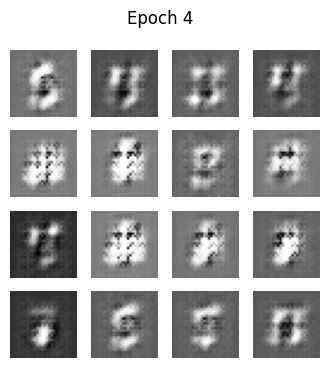

Epoch 5, Gen Loss: 1.1206, Disc Loss: 1.0228


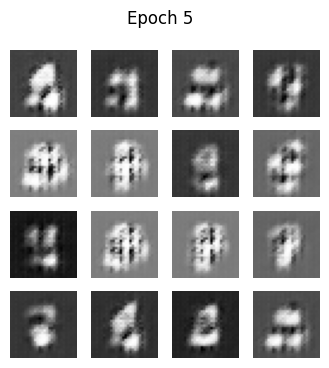

Epoch 6, Gen Loss: 1.1763, Disc Loss: 0.8905


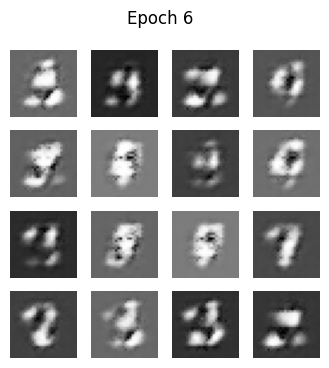

Epoch 7, Gen Loss: 1.5729, Disc Loss: 0.7275


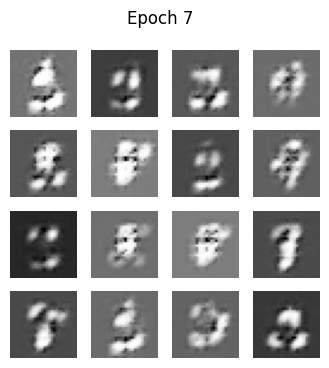

Epoch 8, Gen Loss: 1.4284, Disc Loss: 0.7291


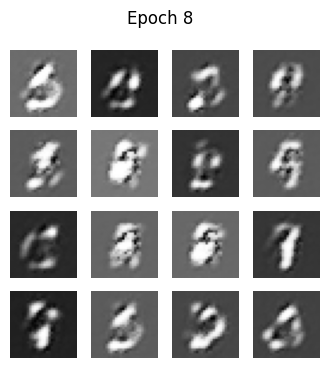

Epoch 9, Gen Loss: 1.7981, Disc Loss: 0.5647


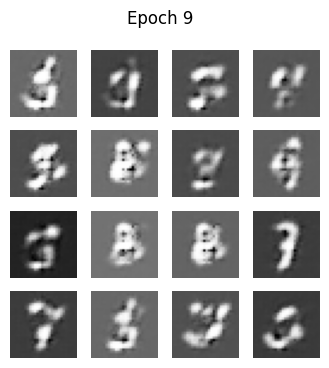

Epoch 10, Gen Loss: 1.9193, Disc Loss: 0.6707


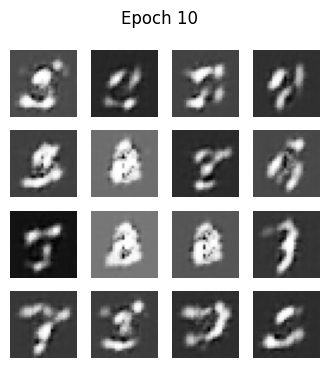

Epoch 11, Gen Loss: 1.8005, Disc Loss: 0.5693


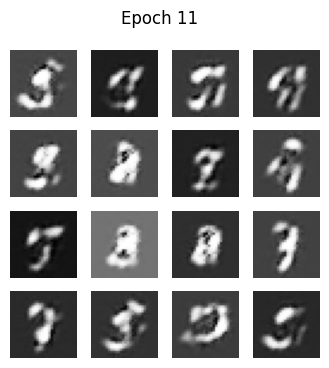

Epoch 12, Gen Loss: 1.8470, Disc Loss: 0.6968


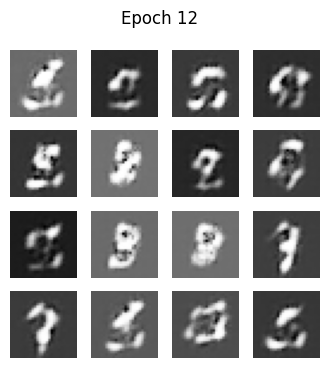

Epoch 13, Gen Loss: 1.9115, Disc Loss: 0.5551


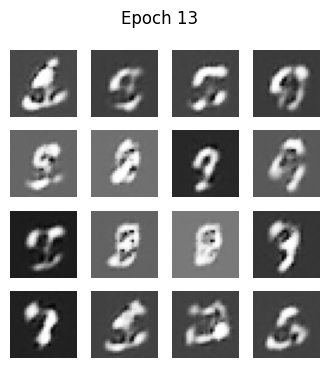

Epoch 14, Gen Loss: 1.8280, Disc Loss: 0.6079


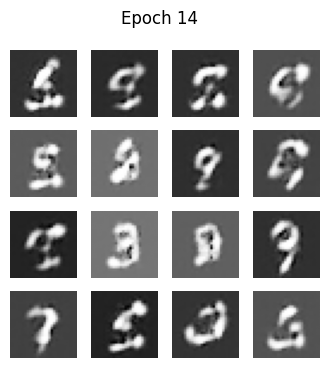

Epoch 15, Gen Loss: 2.2330, Disc Loss: 0.5330


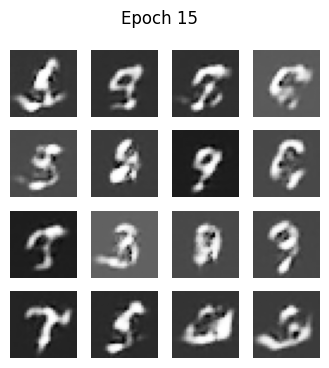

Epoch 16, Gen Loss: 2.0555, Disc Loss: 0.4780


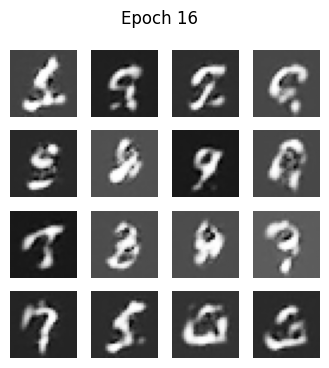

Epoch 17, Gen Loss: 2.1412, Disc Loss: 0.5211


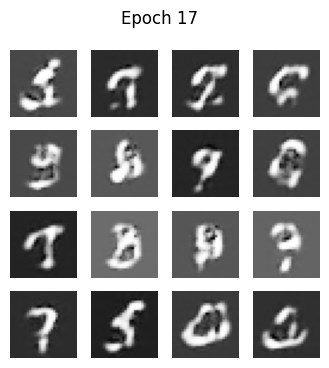

Epoch 18, Gen Loss: 2.0554, Disc Loss: 0.5201


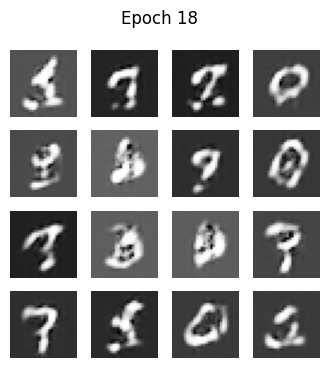

Epoch 19, Gen Loss: 2.0466, Disc Loss: 0.5961


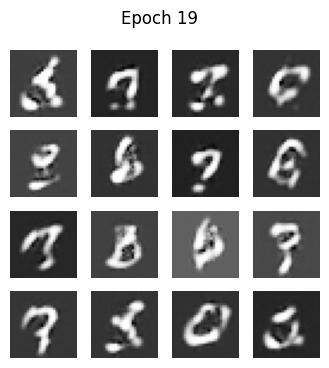

Epoch 20, Gen Loss: 2.0943, Disc Loss: 0.6596


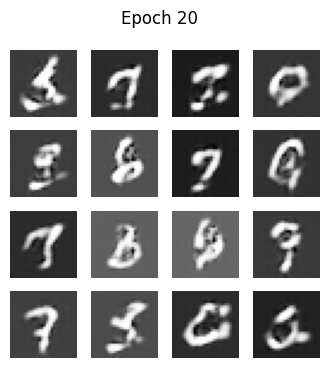

Epoch 21, Gen Loss: 2.0585, Disc Loss: 0.6215


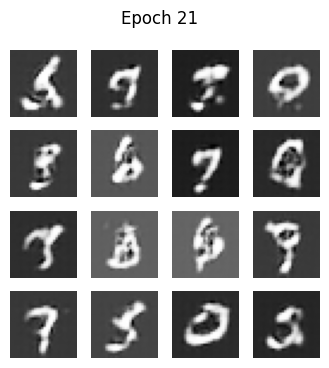

Epoch 22, Gen Loss: 2.3280, Disc Loss: 0.5755


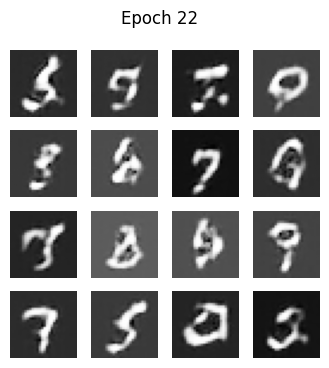

Epoch 23, Gen Loss: 2.2838, Disc Loss: 0.5787


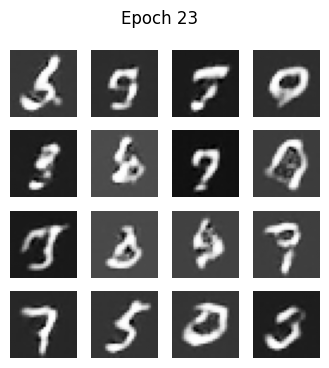

Epoch 24, Gen Loss: 1.8306, Disc Loss: 0.5970


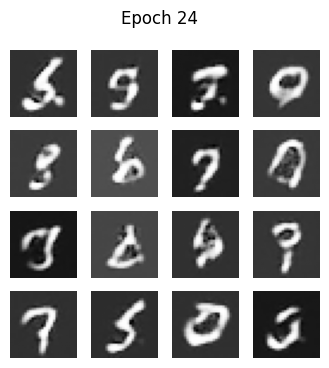

Epoch 25, Gen Loss: 1.9146, Disc Loss: 0.5747


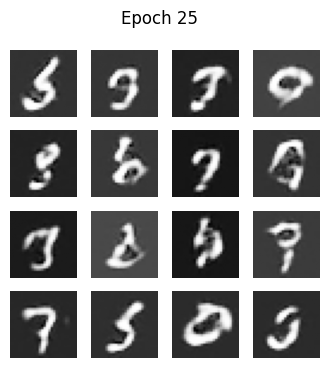

Epoch 26, Gen Loss: 2.0892, Disc Loss: 0.6743


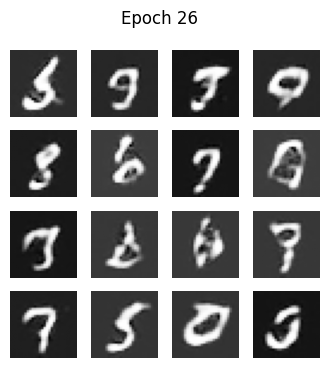

Epoch 27, Gen Loss: 2.0389, Disc Loss: 0.6293


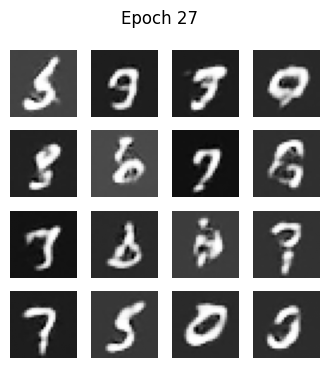

Epoch 28, Gen Loss: 1.9557, Disc Loss: 0.6163


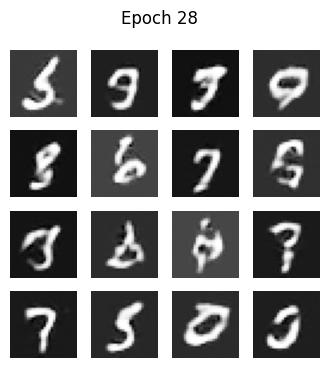

Epoch 29, Gen Loss: 2.2645, Disc Loss: 0.6061


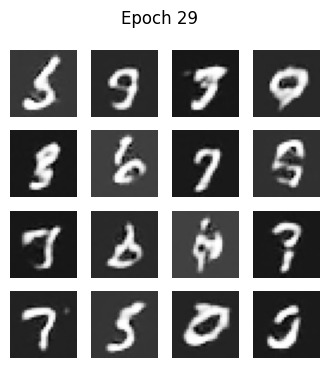

Epoch 30, Gen Loss: 1.8856, Disc Loss: 0.6443


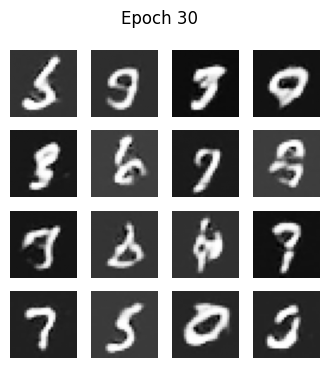

In [7]:
train(train_dataset, EPOCHS)

## 7. 최종 손글씨 생성

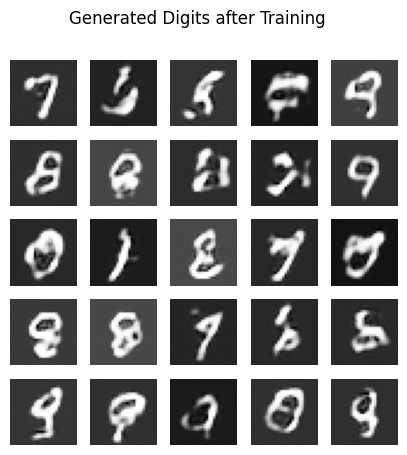

In [8]:
noise = tf.random.normal([25, noise_dim])
generated_images = generator(noise, training=False)

plt.figure(figsize=(5,5))
for i in range(generated_images.shape[0]):
    plt.subplot(5,5,i+1)
    plt.imshow(generated_images[i,:,:,0]*127.5+127.5, cmap="gray")
    plt.axis("off")
plt.suptitle("Generated Digits after Training")
plt.show()

---
## 📝 [실습 5-3 수행 결과 정리]

> 실행 환경: TensorFlow 2.21.0 / Keras 3.15.1 (CPU 2코어). 코드는 원본 그대로 실행했습니다(30 Epoch 학습에 93분 소요). 생성 품질은 학습된 생성자로 1,000장을 더 만들어 **별도 학습한 MNIST CNN 분류기(테스트 정확도 98.75%)**로 판정했습니다.

### 1) 학습 결과 — 손실이 "줄지 않는" 모델

| Epoch | 1 | 2 | 5 | 10 | 15 | 20 | 25 | 30 |
|:---|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| Generator Loss | 0.931 | 0.699 | 1.121 | 1.919 | 2.233 | 2.094 | 1.915 | **1.886** |
| Discriminator Loss | 0.975 | 1.320 | 1.023 | 0.671 | 0.533 | 0.660 | 0.575 | **0.644** |

- AE·VAE·Diffusion과 달리 **두 손실 모두 단조롭게 줄지 않고 진동합니다.** 생성자와 판별자가 서로의 목적을 방해하는 **Minimax 게임**이기 때문입니다. 그래서 GAN은 손실 값만으로 생성 품질을 판단할 수 없고, 매 에포크 샘플 그림(위 출력)을 직접 확인해야 합니다.
- 이론적 균형점은 $D(x) = 0.5$입니다(이때 D Loss = $2\ln 2 \approx 1.386$, G Loss = $\ln 2 \approx 0.693$). Epoch 2가 이 값에 가장 가까웠고, 이후에는 **판별자가 우세**해졌습니다. 학습 후 측정값은 $D(\text{real}) = 0.82$, $D(\text{fake}) = 0.16$입니다.
- 교수님 원본 실행 결과(Epoch 30: G 1.738 / D 0.642)와 같은 양상이 재현되었습니다.

### 2) 생성 결과 — 1,000장 판정

| 지표 | GAN 생성 샘플 | 실제 MNIST (기준) |
|:---|:---:|:---:|
| 분류기 평균 확신도 | 0.818 | 0.982 |
| 확신도 0.9 이상 비율 | 48.6% | 95.2% |
| 클래스 분포 균등도 (정규화 엔트로피) | **0.957** | 0.998 |
| 클래스 비율 (0~9, %) | 7.6 / 4.7 / 5.9 / **19.7** / 7.9 / 6.0 / 9.3 / 12.4 / 10.3 / **16.2** | 약 10씩 |

- 10개 숫자가 모두 생성되어 **Mode Collapse(한두 종류만 생성)는 일어나지 않았습니다.** 다만 '3'(19.7%)과 '9'(16.2%)가 많고 '1'(4.7%)이 적어 분포가 일부 치우쳤습니다. 최종 그리드에도 8·9·3 계열 모양이 자주 보입니다.

### 3) 실행하며 발견한 점 — 데이터 정규화와 `tanh` 출력 범위 불일치

- 실제 데이터는 `x_train / 255.` → **[0, 1]**인데, 생성자 출력층은 `tanh` → **[−1, 1]**입니다. 표준 DCGAN(TensorFlow 튜토리얼)과 Lab 5-4는 `(x − 127.5) / 127.5`로 [−1, 1]에 맞춥니다.
- 측정해 보면 생성자가 스스로 **tanh의 절반([0, 1])만 쓰도록 적응**했습니다. 생성 이미지 평균 0.138(실제 0.131), 배경(모서리 4×4) 평균 ≈ 0.00005, −0.5 미만 픽셀 0.004%입니다.
- 이 때문에 출력 그림의 **배경이 검은색이 아니라 회색이고 이미지마다 밝기가 다릅니다.** 시각화 식 `*127.5+127.5`가 [−1, 1]을 가정하므로 배경 0이 127.5(회색)로 바뀌고, `imshow`가 이미지마다 최소·최대로 자동 스케일하기 때문입니다. 교수님 원본 출력에도 같은 현상이 있습니다.
- 개선안: `x_train = (x_train.astype("float32") - 127.5) / 127.5` 한 줄이면 데이터와 출력 범위가 맞고 시각화도 올바르게 복원됩니다. 판별자가 값의 범위만으로 진짜/가짜를 구분하는 단서도 사라집니다.

### 4) 📊 생성 모델 3종 비교 (Lab 5-2 · 5-3 · 5-4, 같은 분류기 기준)

| 모델 | 평균 확신도 | 확신도 0.9 이상 | 클래스 균등도 | 주된 실패 양상 | 학습 시간 (이 환경) | 1장 생성 시 네트워크 통과 |
|:---|:---:|:---:|:---:|:---|:---:|:---:|
| VAE (잠재 2D, 20 Ep) | 0.827 | 51.2% | 0.918 | 흐릿함, '4' 거의 미생성(0.2%) | 약 13~16분 | 1회 |
| **GAN** (30 Ep) | 0.818 | 48.6% | **0.957** | 번짐·끊긴 획, 회색 배경(정규화 불일치) | 93분 | 1회 |
| Diffusion (T=200, 10 Ep) | 0.826 | 52.5% | 0.923 | 선명하지만 구조가 어긋난 모양 | 30분 | **200회** |
| 실제 MNIST | 0.982 | 95.2% | 0.998 | – | – | – |

- 실습 규모(적은 에포크, 작은 네트워크, CPU)에서는 세 모델의 인식 가능도가 **모두 0.82 수준으로 비슷**합니다. 교과서의 "Diffusion > GAN > VAE" 품질 순위는 충분한 학습량과 모델 크기를 전제로 한 것임을 알 수 있습니다. 대신 **실패 양상, 다양성, 생성 비용**에서 뚜렷한 차이가 났습니다.

### 5) 핵심 정리 및 제조 AI 시사점
1. GAN은 판별자를 "학습되는 손실 함수"로 삼아 픽셀 평균 오차 없이 학습합니다. 그래서 VAE보다 날카로운 샘플을 **한 번의 추론으로 빠르게** 만듭니다.
2. 대신 손실이 품질 지표가 되지 못하고 균형이 쉽게 깨지므로(이번에도 판별자 우세) **샘플을 직접 점검하는 모니터링**이 필수입니다.
3. 제조 불량 데이터 증강에 쓸 때는 생성된 결함 **유형별 분포**를 반드시 확인해야 합니다. 이번 실험처럼 특정 클래스가 과다하거나 부족하면 증강 데이터로 학습한 검사 모델도 편향됩니다. 또한 **입력 정규화 범위와 출력 활성화 범위를 일치**시키는 것이 기본 전제입니다.